# Building a model with Decision Tree

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
atm = pd.read_csv(r'Dataset/ATM_Maintenance_Cleaned.csv', parse_dates=['Date'])
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,Idukki,Hospital,NCR,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,Kozhikode,Railway,Diebold,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,Malappuram,Airport,Diebold,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,Alappuzha,Rural,Diebold,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,Thrissur,Hospital,NCR,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,Kottayam,Airport,Diebold,8.1,595,29,69.0,0,...,58,177,0,79,3,5,0,0,1,1
49996,2025-12-23,ATM229,Kollam,Airport,Hitachi,7.3,578,11,85.0,1,...,67,41,3,77,3,70,6,1,0,0
49997,2025-12-24,ATM247,Thrissur,Hospital,Diebold,6.2,656,1,35.0,0,...,65,64,0,89,0,43,4,2,0,0
49998,2025-12-25,ATM184,Kottayam,Railway,NCR,1.9,471,19,62.0,0,...,71,114,0,100,1,0,2,3,1,1


In [3]:
from sklearn.preprocessing import LabelEncoder

In [4]:
le = LabelEncoder()

In [5]:
atm['District'] = le.fit_transform(atm['District'])
atm['Location_Type'] = le.fit_transform(atm['Location_Type'])
atm['Manufacturer'] = le.fit_transform(atm['Manufacturer'])

In [6]:
X = atm.drop(columns=['ATM_ID', 'Date', 'Failure_Next_48H'])
y = atm['Failure_Next_48H']

In [7]:
X

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code
0,2,2,2,1.2,429,15,69.0,0,2,3,...,29,52,46,0,78,2,29,4,1,5
1,6,4,0,1.9,343,6,43.0,0,0,3,...,50,45,10,0,92,3,58,1,0,2
2,7,0,0,2.5,285,10,78.0,0,2,1,...,65,53,66,2,88,0,63,0,0,0
3,0,5,0,4.6,488,22,39.0,0,2,2,...,84,67,95,1,68,1,54,0,0,5
4,9,2,2,8.7,736,25,57.0,0,2,2,...,74,54,56,3,97,4,57,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5,0,0,8.1,595,29,69.0,0,1,3,...,32,58,177,0,79,3,5,0,0,1
49996,4,0,1,7.3,578,11,85.0,1,2,2,...,12,67,41,3,77,3,70,6,1,0
49997,9,2,0,6.2,656,1,35.0,0,1,0,...,49,65,64,0,89,0,43,4,2,0
49998,5,4,2,1.9,471,19,62.0,0,2,3,...,21,71,114,0,100,1,0,2,3,1


In [8]:
y

0        1
1        1
2        0
3        1
4        0
        ..
49995    1
49996    0
49997    0
49998    1
49999    0
Name: Failure_Next_48H, Length: 50000, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code
39087,0,1,2,5.4,601,17,37.0,0,0,3,...,25,65,72,1,100,0,5,1,2,5
30893,8,0,2,1.3,613,19,27.0,0,2,1,...,29,59,62,0,81,3,19,3,2,0
45278,5,4,0,9.5,337,8,49.0,1,1,3,...,33,67,33,4,90,3,50,0,0,5
16398,6,5,0,8.4,157,3,42.0,1,2,2,...,29,58,16,0,93,2,36,0,0,0
13653,8,0,0,1.9,422,15,76.0,0,0,3,...,26,57,82,1,83,0,41,4,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,9,4,0,4.8,346,1,45.0,0,1,0,...,64,61,35,0,99,4,24,0,1,0
44732,1,0,2,6.3,25,0,37.0,0,0,3,...,39,62,31,3,86,1,52,0,2,1
38158,7,5,0,9.3,699,9,79.0,0,1,3,...,67,83,74,0,100,0,44,0,0,2
860,7,1,1,9.2,336,0,46.0,1,2,3,...,53,39,39,0,87,0,65,0,0,1


In [12]:
X_test

,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,CardReader_Errors,CashDispenser_Errors,...,CPU_Usage_Pct,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code
33553,0,4,1,2.2,493,14,55.0,1,0,0,...,35,74,68,2,80,4,57,1,3,0
9427,0,0,1,5.3,640,8,75.0,0,0,3,...,53,56,21,1,92,3,45,0,0,2
199,9,2,1,2.4,447,20,50.0,1,2,1,...,38,54,110,0,89,0,7,0,0,0
12447,6,2,2,5.8,490,11,28.0,0,1,1,...,40,50,17,2,100,1,17,2,0,0
39489,4,0,1,1.3,481,4,72.0,1,0,1,...,24,68,80,1,86,0,33,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28567,2,5,1,4.9,479,4,56.0,0,1,2,...,48,55,61,2,96,3,40,1,0,0
25079,4,0,2,5.6,425,0,62.0,0,2,0,...,35,50,42,0,98,1,68,6,4,6
18707,1,4,1,8.8,281,9,43.0,0,1,3,...,35,56,133,2,77,0,22,0,2,3
15200,8,5,1,3.4,376,7,86.0,0,1,2,...,47,72,59,1,83,0,17,0,0,0


In [13]:
y_train

39087    1
30893    0
45278    1
16398    0
13653    1
        ..
11284    0
44732    1
38158    1
860      1
15795    1
Name: Failure_Next_48H, Length: 40000, dtype: int64

In [14]:
y_test

33553    0
9427     1
199      0
12447    0
39489    0
        ..
28567    0
25079    1
18707    1
15200    0
5857     0
Name: Failure_Next_48H, Length: 10000, dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled

array([[-1.56777311, -0.86396953,  1.21730706, ..., -0.04699399,
         0.69937635,  1.68791994],
       [ 1.21956491, -1.44916606,  1.21730706, ...,  1.42271631,
         0.69937635, -0.71228474],
       [ 0.17431315,  0.89162006, -1.23163336, ..., -0.78184913,
        -0.78494763,  1.68791994],
       ...,
       [ 0.87114766,  1.4768166 , -1.23163336, ..., -0.78184913,
        -0.78494763,  0.24779713],
       [ 0.87114766, -0.86396953, -0.00716315, ..., -0.78184913,
        -0.78494763, -0.2322438 ],
       [-0.87093861, -1.44916606, -1.23163336, ..., -0.78184913,
        -0.04278564,  0.24779713]], shape=(40000, 24))

In [19]:
X_test_scaled

array([[-1.56777311,  0.89162006, -0.00716315, ..., -0.04699399,
         1.44153834, -0.71228474],
       [-1.56777311, -1.44916606, -0.00716315, ..., -0.78184913,
        -0.78494763,  0.24779713],
       [ 1.56798216, -0.278773  , -0.00716315, ..., -0.78184913,
        -0.78494763, -0.71228474],
       ...,
       [-1.21935586,  0.89162006, -0.00716315, ..., -0.78184913,
         0.69937635,  0.72783807],
       [ 1.21956491,  1.4768166 , -0.00716315, ..., -0.78184913,
        -0.78494763, -0.71228474],
       [ 0.87114766,  0.89162006,  1.21730706, ..., -0.78184913,
         0.69937635, -0.71228474]], shape=(10000, 24))

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

In [22]:
model.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [23]:
y_pred = model.predict(X_test_scaled)
y_pred

array([0, 1, 0, ..., 1, 0, 0], shape=(10000,))

In [24]:
from sklearn.tree import plot_tree

In [25]:
feature_names = X.columns

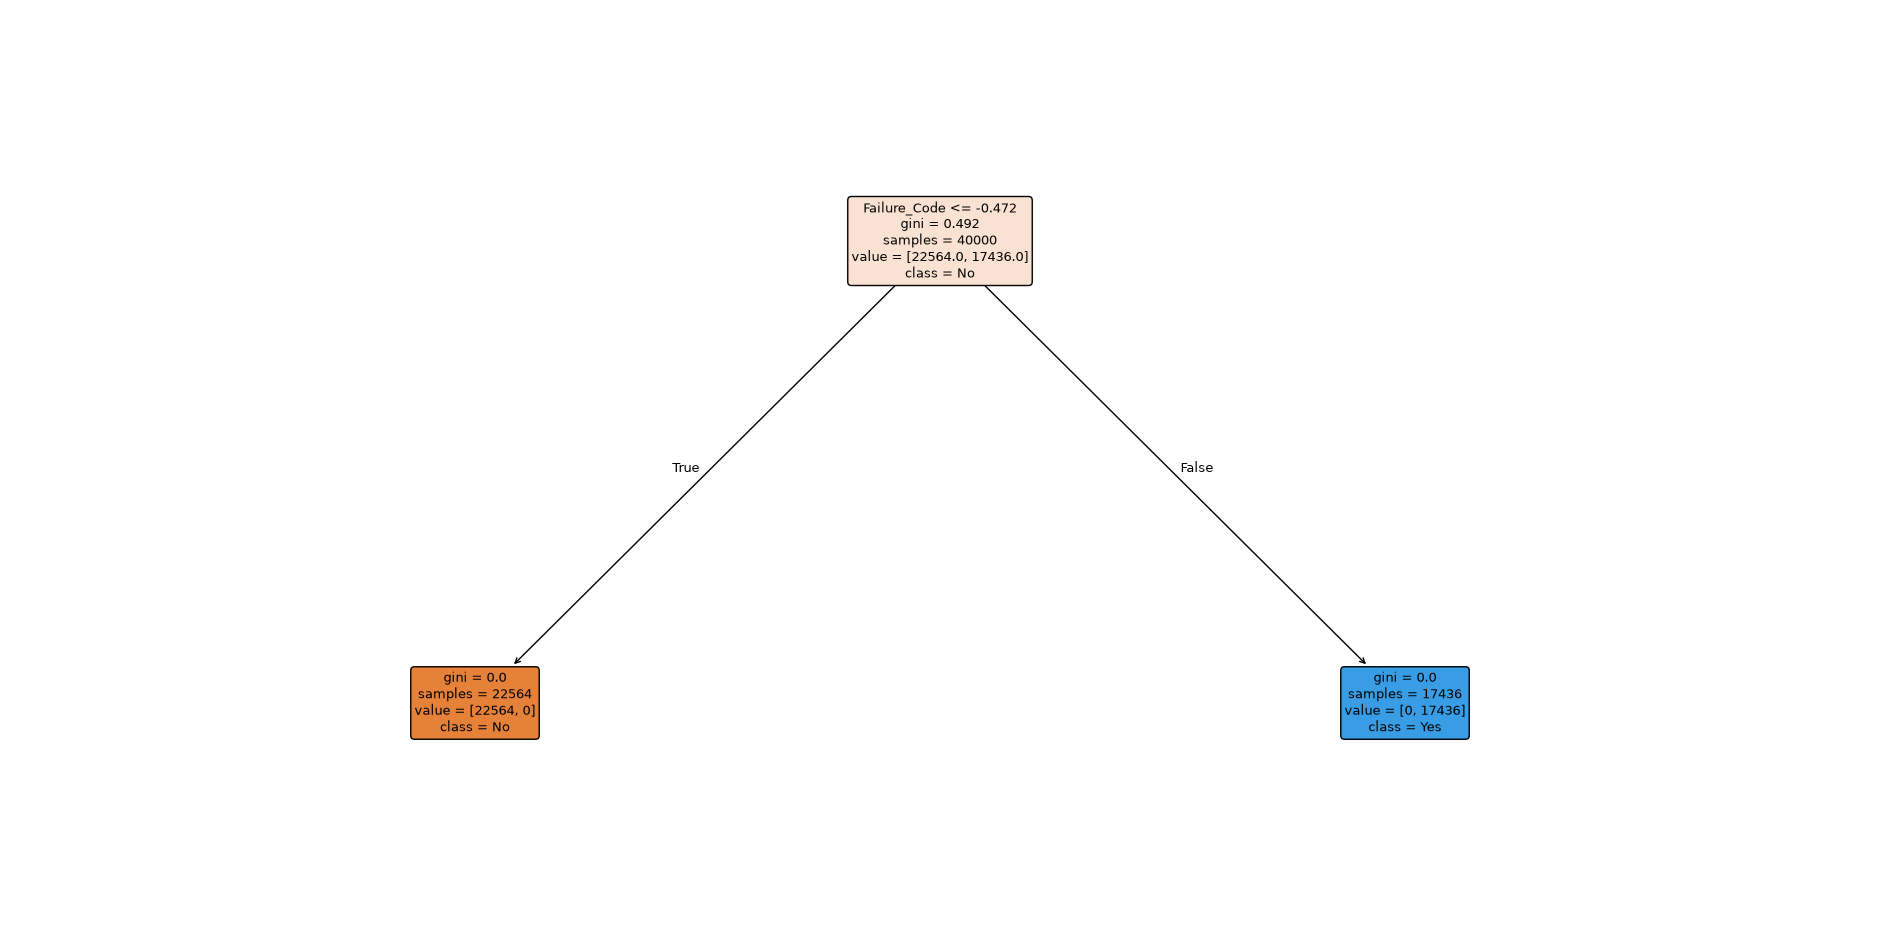

In [26]:
plt.figure(figsize=(24,12))
plot_tree(model, feature_names = X.columns, class_names=['No','Yes'], filled=True, rounded=True, fontsize=9)
plt.show()

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

1.0

In [33]:
precision = precision_score(y_test,y_pred, average='weighted')
precision

1.0

In [34]:
recall = recall_score(y_test,y_pred, average='weighted')
recall

1.0

In [35]:
f1 = f1_score(y_test,y_pred, average='weighted')
f1

1.0

In [36]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
